<a href="https://colab.research.google.com/github/fergogu27-ctrl/EDPII/blob/main/bootstrap_tiempos_entrega_comentado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bootstrap para estimar la media de tiempos de entrega

En este notebook se aplica el método Bootstrap a una muestra de 12 tiempos de entrega.

El objetivo es:

1. Usar la muestra original.
2. Generar 1000 muestras Bootstrap con reemplazo.
3. Calcular la media de cada muestra Bootstrap.
4. Obtener la media Bootstrap.
5. Calcular la desviación estándar Bootstrap.
6. Calcular los percentiles 2.5% y 97.5%.
7. Construir un intervalo de confianza Bootstrap al 95%.

In [1]:
# Importamos las librerías necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 1. Definición de la muestra original

La muestra contiene 12 tiempos de entrega.

In [2]:
# Esta es la muestra aleatoria de 12 tiempos de entrega que aparece en el pizarrón
datos = np.array([35, 42, 38, 40, 45, 37, 39, 41, 44, 36, 43, 40])

# Guardamos el tamaño de la muestra original
# En este caso n = 12
n = len(datos)

# Mostramos la muestra original
print('Muestra original:')
print(datos)

print('\nTamaño de la muestra:')
print(n)

Muestra original:
[35 42 38 40 45 37 39 41 44 36 43 40]

Tamaño de la muestra:
12


## 2. Media de la muestra original

Calculamos la media muestral de los 12 tiempos de entrega.

In [3]:
# La media muestral es el promedio de los 12 tiempos de entrega
media_original = np.mean(datos)

print('Media de la muestra original:')
print(media_original)

Media de la muestra original:
40.0


## 3. Generación de muestras Bootstrap

Una muestra Bootstrap se obtiene tomando datos de la muestra original con reemplazo.

Esto significa que un mismo valor puede aparecer más de una vez en una misma muestra Bootstrap.

In [4]:
# Número de muestras bootstrap que queremos generar
B = 1000

# Creamos un generador aleatorio
rng = np.random.default_rng()

muestras_bootstrap = rng.choice(
    datos,          # datos originales de donde vamos a remuestrear
    size=(B, n),    # 1000 muestras, cada una de tamaño 12
    replace=True    # muestreo con reemplazo
)

# Mostramos las primeras 5 muestras bootstrap
print('Primeras 5 muestras bootstrap:')
print(muestras_bootstrap[:5])

Primeras 5 muestras bootstrap:
[[45 43 38 38 39 41 35 38 41 39 35 39]
 [40 41 41 45 44 36 36 37 42 41 40 38]
 [35 40 42 35 40 39 38 45 39 35 42 45]
 [40 37 39 40 44 40 35 45 45 37 37 40]
 [39 38 37 42 36 41 42 38 41 39 40 39]]


## 4. Media de cada muestra Bootstrap

Ahora calculamos el promedio de cada una de las 1000 muestras Bootstrap.

In [5]:
# Para cada una de las 1000 muestras bootstrap calculamos su media
medias_bootstrap = np.mean(muestras_bootstrap, axis=1)

# Mostramos las primeras 10 medias bootstrap
print('Primeras 10 medias bootstrap:')
print(medias_bootstrap[:10])

Primeras 10 medias bootstrap:
[39.25       40.08333333 39.58333333 39.91666667 39.33333333 38.91666667
 40.08333333 39.5        40.16666667 39.58333333]


## 5. Media de las medias Bootstrap

Esta cantidad resume el promedio de todas las medias obtenidas por Bootstrap.

In [6]:
# Esta cantidad resume el promedio de todas las medias bootstrap
media_de_medias_bootstrap = np.mean(medias_bootstrap)

print('Media de las medias bootstrap:')
print(media_de_medias_bootstrap)

Media de las medias bootstrap:
40.008333333333326


## 6. Desviación estándar Bootstrap

La desviación estándar de las medias Bootstrap se interpreta como una estimación del error estándar de la media.

In [7]:

desviacion_estandar_bootstrap = np.std(medias_bootstrap, ddof=1)

print('Desviación estándar bootstrap:')
print(desviacion_estandar_bootstrap)

Desviación estándar bootstrap:
0.8836573401150378


## 7. Percentiles 2.5% y 97.5%

Para construir un intervalo de confianza Bootstrap al 95%, usamos los percentiles 2.5% y 97.5%.

In [8]:
# Para construir un intervalo de confianza bootstrap al 95%,
# usamos los percentiles 2.5% y 97.5%
percentil_025 = np.percentile(medias_bootstrap, 2.5)
percentil_975 = np.percentile(medias_bootstrap, 97.5)

print('Percentil 2.5%:')
print(percentil_025)

print('\nPercentil 97.5%:')
print(percentil_975)

Percentil 2.5%:
38.333333333333336

Percentil 97.5%:
41.75


## 8. Intervalo de confianza Bootstrap al 95%

El intervalo queda dado por:
$$[P_{2.5}, P_{97.5}]$$

donde $P_{2.5}$ y $P_{97.5}$ son los percentiles 2.5% y 97.5% de las medias Bootstrap.

In [9]:
# El intervalo bootstrap al 95% queda formado por:
# [percentil 2.5%, percentil 97.5%]
intervalo_confianza = (percentil_025, percentil_975)

print('Intervalo de confianza Bootstrap al 95%:')
print(intervalo_confianza)

Intervalo de confianza Bootstrap al 95%:
(np.float64(38.333333333333336), np.float64(41.75))


## 9. Resumen final de resultados

In [10]:
print('Resumen del procedimiento Bootstrap')
print('-----------------------------------')
print(f'Media original: {media_original:.4f}')
print(f'Media de las medias bootstrap: {media_de_medias_bootstrap:.4f}')
print(f'Desviación estándar bootstrap: {desviacion_estandar_bootstrap:.4f}')
print(f'Percentil 2.5%: {percentil_025:.4f}')
print(f'Percentil 97.5%: {percentil_975:.4f}')
print(f'Intervalo de confianza al 95%: [{percentil_025:.4f}, {percentil_975:.4f}]')

Resumen del procedimiento Bootstrap
-----------------------------------
Media original: 40.0000
Media de las medias bootstrap: 40.0083
Desviación estándar bootstrap: 0.8837
Percentil 2.5%: 38.3333
Percentil 97.5%: 41.7500
Intervalo de confianza al 95%: [38.3333, 41.7500]


## 10. Tabla con algunas muestras Bootstrap

Mostramos las primeras 10 muestras Bootstrap junto con su media.

In [11]:
# Convertimos las primeras 10 muestras bootstrap en una tabla
tabla_bootstrap = pd.DataFrame(
    muestras_bootstrap[:10],
    columns=[f'X{i+1}' for i in range(n)]
)

# Agregamos una columna con la media de cada muestra bootstrap
tabla_bootstrap['Media'] = medias_bootstrap[:10]

# Mostramos la tabla
tabla_bootstrap

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12,Media
0,45,43,38,38,39,41,35,38,41,39,35,39,39.250000
1,40,41,41,45,44,36,36,37,42,41,40,38,40.083333
2,35,40,42,35,40,39,38,45,39,35,42,45,39.583333
3,40,37,39,40,44,40,35,45,45,37,37,40,39.916667
4,39,38,37,42,36,41,42,38,41,39,40,39,39.333333
5,44,40,44,37,37,35,35,40,45,40,35,35,38.916667
6,39,38,43,36,41,39,44,44,38,37,41,41,40.083333
7,40,37,40,37,45,44,40,44,35,40,35,37,39.500000
8,37,45,42,43,37,41,39,45,35,36,43,39,40.166667
9,43,41,36,40,40,39,40,37,41,35,39,44,39.583333


## 11. Gráfica de la distribución Bootstrap de la media

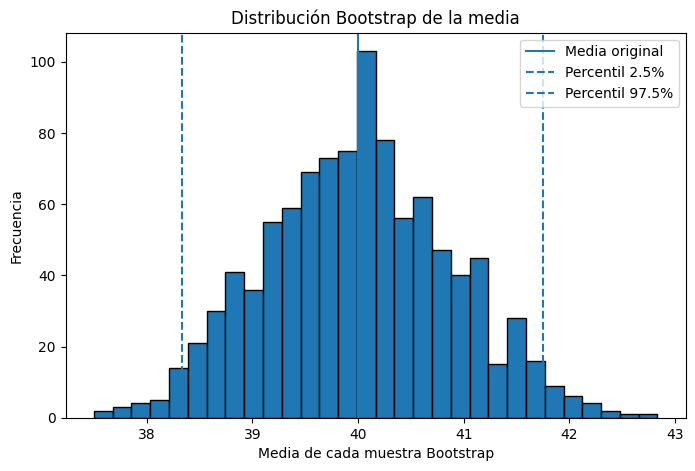

In [12]:
plt.figure(figsize=(8, 5))

# Histograma de las medias bootstrap
plt.hist(medias_bootstrap, bins=30, edgecolor='black')

# Línea vertical para la media original
plt.axvline(media_original, linestyle='-', label='Media original')

# Líneas verticales para los percentiles del intervalo
plt.axvline(percentil_025, linestyle='--', label='Percentil 2.5%')
plt.axvline(percentil_975, linestyle='--', label='Percentil 97.5%')

# Títulos y etiquetas
plt.title('Distribución Bootstrap de la media')
plt.xlabel('Media de cada muestra Bootstrap')
plt.ylabel('Frecuencia')

# Mostramos leyenda
plt.legend()

# Mostramos la gráfica
plt.show()

## Interpretación

El intervalo de confianza Bootstrap al 95% se interpreta como un intervalo estimado para la media verdadera de los tiempos de entrega.

Como no se fijó semilla, los resultados pueden cambiar ligeramente cada vez que se ejecute el notebook.